# Gradient Descent — Linear Regression

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Data

In [3]:
np.random.seed(42)
X = 2 * np.random.rand(100)
y = 4 + 3 * X + np.random.randn(100)

## Step 1 — Initialize

In [4]:
theta0 = 0.0
theta1 = 0.0
learning_rate = 0.01
max_iterations = 1000
m = len(X)

## Step 2 — Predict

In [5]:
def predict(X, theta0, theta1):
    return theta0 + theta1 * X

## Step 3 — Cost Function

In [6]:
def compute_cost(X, y, theta0, theta1):
    m = len(y)
    y_hat = predict(X, theta0, theta1)
    return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)

## Steps 4, 5, 6 — Gradient Descent Loop

In [7]:
cost_history = []

for i in range(max_iterations):
    y_hat = predict(X, theta0, theta1)
    error = y_hat - y

    cost_history.append((1 / (2 * m)) * np.sum(error ** 2))

    grad_theta0 = (1 / m) * np.sum(error)
    grad_theta1 = (1 / m) * np.sum(error * X)

    theta0 = theta0 - learning_rate * grad_theta0
    theta1 = theta1 - learning_rate * grad_theta1

    if i > 0 and abs(cost_history[-2] - cost_history[-1]) < 1e-9:
        break

print(f'theta0 = {theta0:.4f}')
print(f'theta1 = {theta1:.4f}')

theta0 = 4.0332
theta1 = 2.9307


## Visualizations

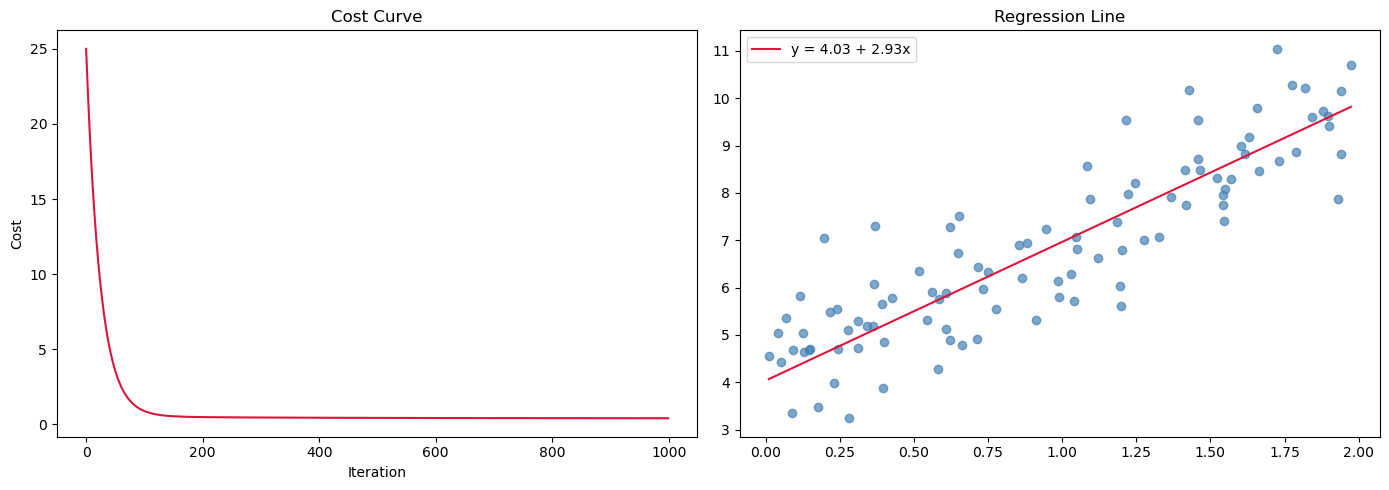

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_history, color='crimson')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Cost')
axes[0].set_title('Cost Curve')

x_line = np.linspace(X.min(), X.max(), 200)
y_line = theta0 + theta1 * x_line

axes[1].scatter(X, y, alpha=0.7, color='steelblue')
axes[1].plot(x_line, y_line, color='crimson',
             label=f'y = {theta0:.2f} + {theta1:.2f}x')
axes[1].set_title('Regression Line')
axes[1].legend()

plt.tight_layout()
plt.show()